# Text Splitter Evaluation for RAG4GOV

This notebook evaluates different text splitting strategies for optimal RAG performance:
1. RecursiveCharacterTextSplitter
2. CharacterTextSplitter
3. TokenTextSplitter
4. ContextAwareSplitter

We'll evaluate these splitters on:
- Chunk consistency
- Context preservation
- Processing speed
- Memory usage
- Semantic coherence

In [1]:
!pip install memory_profiler seaborn tiktoken


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing Libraries

These are the libraries we are importing
- pdfplumber
- pandas
- numpy
- typing
- matplotlib.pyplot
- seaborn
- memory_profiler
- langchain_text_splitters
- langchain_core

In [2]:
import os
import sys
import time
import pdfplumber
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from typing import List, Dict
import matplotlib.pyplot as plt
import seaborn as sns
from memory_profiler import profile
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
    TokenTextSplitter
)
from langchain_core.documents import Document

# Add src to path
src_path = str(Path.cwd().parent / 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# Configure plotting
plt.style.use('default')
sns.set_palette('husl')

# Creating a class Context aware splitter

This class will be used for preserving the semantic of a particular document

In [3]:
class ContextAwareSplitter:
    """Custom splitter that preserves semantic context."""
    
    def __init__(self, chunk_size=1000, chunk_overlap=200):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        
    def split_documents(self, documents: List[Document]) -> List[Document]:
        """Split documents while preserving context."""
        splits = []
        for doc in documents:
            # Split on paragraph boundaries
            paragraphs = doc.page_content.split('\n\n')
            current_chunk = []
            current_size = 0
            
            for para in paragraphs:
                para_size = len(para)
                
                if current_size + para_size > self.chunk_size:
                    if current_chunk:  # Add accumulated paragraphs as a chunk
                        splits.append(Document(
                            page_content='\n\n'.join(current_chunk),
                            metadata=doc.metadata
                        ))
                    current_chunk = [para]
                    current_size = para_size
                else:
                    current_chunk.append(para)
                    current_size += para_size
            
            # Add the last chunk
            if current_chunk:
                splits.append(Document(
                    page_content='\n\n'.join(current_chunk),
                    metadata=doc.metadata
                ))
                
        return splits

# Function to load pdf

This function loads pdf and creates a document with metadata {'source' , 'page'}

In [4]:
def load_pdf_content(pdf_path: str) -> List[Document]:
    """Load PDF content using pdfplumber."""
    documents = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages, 1):
            text = page.extract_text()
            if text:
                documents.append(Document(
                    page_content=text,
                    metadata={
                        'source': pdf_path,
                        'page': page_num
                    }
                ))
    
    return documents


def evaluate_splitter(splitter, documents: List[Document]) -> Dict:
    """Evaluate a text splitter's performance."""
    start_time = time.time()
    
    # Split documents
    splits = splitter.split_documents(documents)
    
    # Calculate metrics
    processing_time = time.time() - start_time
    chunk_sizes = [len(split.page_content) for split in splits]
    
    return {
        'num_chunks': len(splits),
        'avg_chunk_size': np.mean(chunk_sizes),
        'std_chunk_size': np.std(chunk_sizes),
        'min_chunk_size': min(chunk_sizes),
        'max_chunk_size': max(chunk_sizes),
        'processing_time': processing_time,
        'chunks': splits
    }

# Load test PDFs
pdf_folder = "../public"
pdf_paths = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]
all_documents = []

for pdf_path in pdf_paths:
    full_path = os.path.join(pdf_folder, pdf_path)
    all_documents.extend(load_pdf_content(full_path))

print(f"Loaded {len(all_documents)} pages from {len(pdf_paths)} PDFs")

Loaded 136 pages from 3 PDFs


# Defining different splitters and there evalutaion

- RecursiveCharacter
- Character
- Token
- ContextAware

In [5]:
# Initialize splitters
splitters = {
    'RecursiveCharacter': RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    ),
    'Character': CharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    ),
    'Token': TokenTextSplitter(
        chunk_size=500,  # tokens
        chunk_overlap=50
    ),
    'ContextAware': ContextAwareSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )
}

# Evaluate each splitter
results = {}
for name, splitter in tqdm(splitters.items(), desc="Evaluating splitters"):
    results[name] = evaluate_splitter(splitter, all_documents)

# Convert results to DataFrame
df_results = pd.DataFrame([
    {
        'Splitter': name,
        'Number of Chunks': data['num_chunks'],
        'Avg Chunk Size': data['avg_chunk_size'],
        'Std Chunk Size': data['std_chunk_size'],
        'Processing Time (s)': data['processing_time']
    }
    for name, data in results.items()
])

df_results

Evaluating splitters:   0%|          | 0/4 [00:00<?, ?it/s]

,Splitter,Number of Chunks,Avg Chunk Size,Std Chunk Size,Processing Time (s)
0,RecursiveCharacter,334,817.242515,224.067765,0.006915
1,Character,136,1766.176471,669.766003,0.002604
2,Token,187,1341.459893,674.805951,0.036622
3,ContextAware,136,1766.176471,669.766003,0.000795


## Visualization of Results

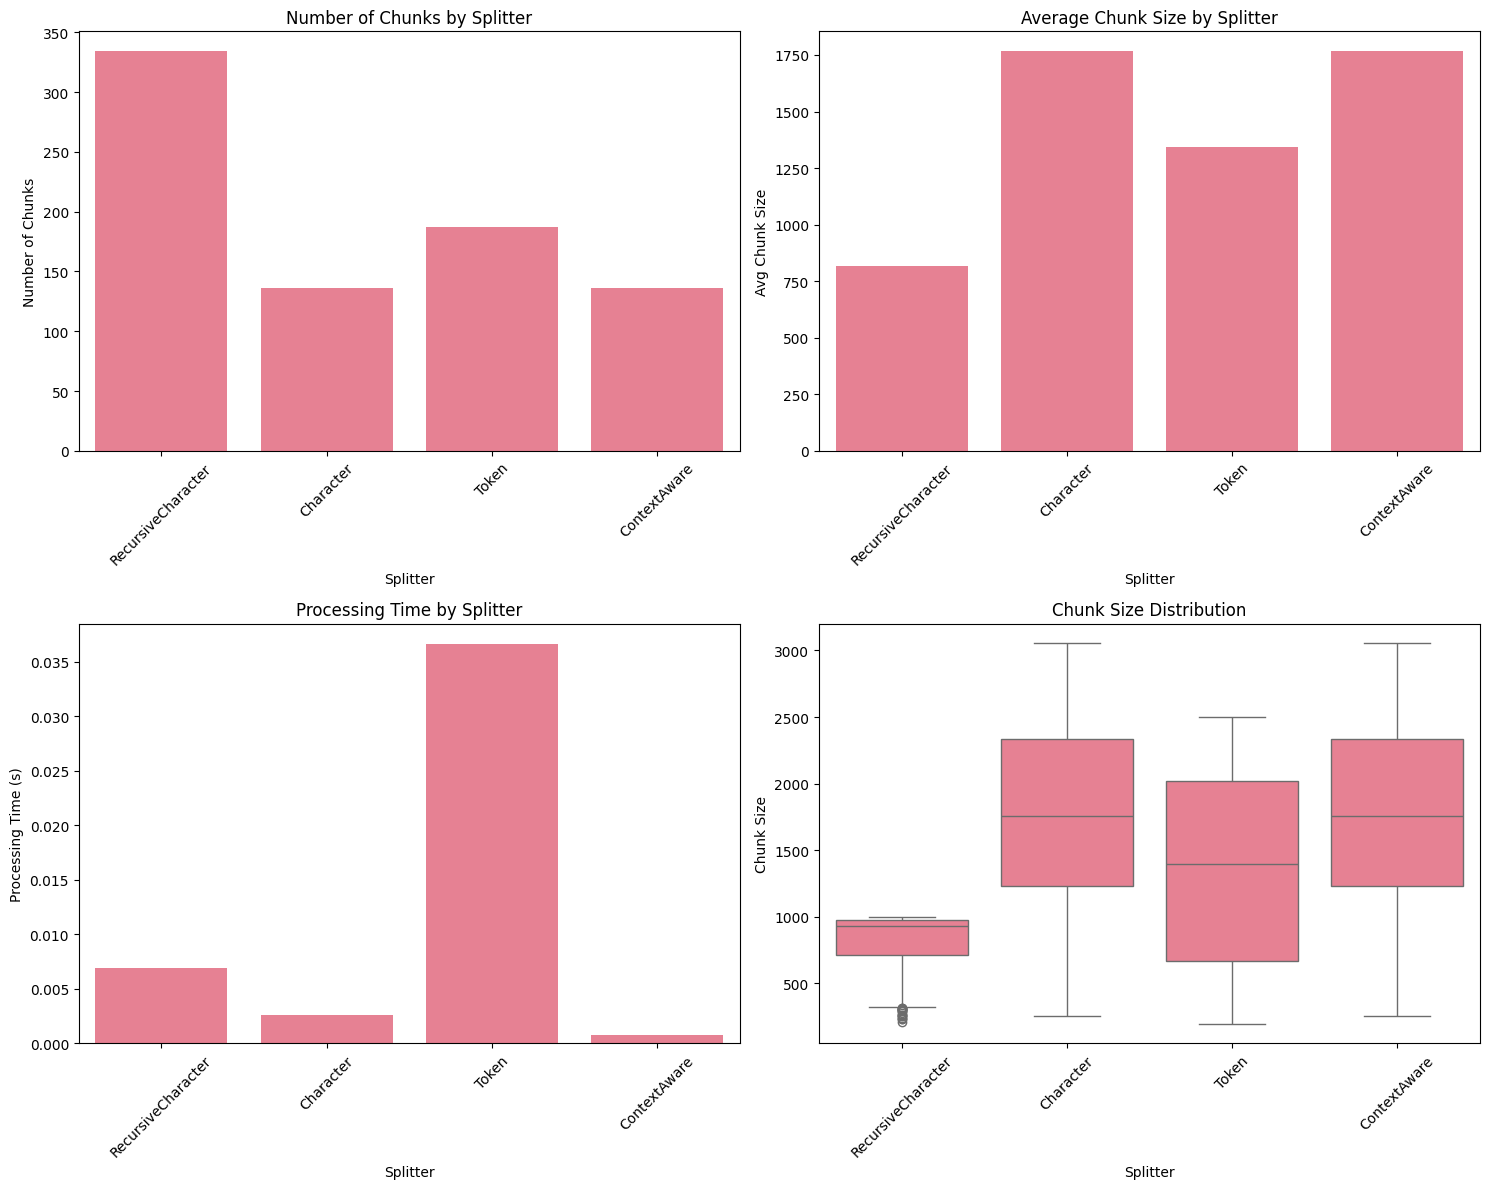

In [6]:
# Create visualization grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Number of Chunks
sns.barplot(data=df_results, x='Splitter', y='Number of Chunks', ax=axes[0, 0])
axes[0, 0].set_title('Number of Chunks by Splitter')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average Chunk Size
sns.barplot(data=df_results, x='Splitter', y='Avg Chunk Size', ax=axes[0, 1])
axes[0, 1].set_title('Average Chunk Size by Splitter')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Processing Time
sns.barplot(data=df_results, x='Splitter', y='Processing Time (s)', ax=axes[1, 0])
axes[1, 0].set_title('Processing Time by Splitter')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Chunk Size Distribution
chunk_sizes = pd.DataFrame([
    {'Splitter': name, 'Chunk Size': len(chunk.page_content)}
    for name, data in results.items()
    for chunk in data['chunks']
])

sns.boxplot(data=chunk_sizes, x='Splitter', y='Chunk Size', ax=axes[1, 1])
axes[1, 1].set_title('Chunk Size Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Semantic Coherence Analysis

In [7]:
def analyze_semantic_coherence(chunks: List[Document]) -> Dict:
    """Analyze semantic coherence of chunks."""
    metrics = {
        'complete_sentences': 0,
        'paragraph_breaks': 0,
        'section_headers': 0
    }
    
    for chunk in chunks:
        text = chunk.page_content
        
        # Check for complete sentences (rough heuristic)
        sentences = text.split('.')
        if text.strip().endswith(('.', '!', '?')):
            metrics['complete_sentences'] += 1
            
        # Check for paragraph breaks
        if '\n\n' in text:
            metrics['paragraph_breaks'] += 1
            
        # Check for section headers (rough heuristic)
        lines = text.split('\n')
        for line in lines:
            if line.strip().isupper() or line.strip().endswith(':'):
                metrics['section_headers'] += 1
                break
    
    total_chunks = len(chunks)
    return {
        'complete_sentences_ratio': metrics['complete_sentences'] / total_chunks,
        'paragraph_breaks_ratio': metrics['paragraph_breaks'] / total_chunks,
        'section_headers_ratio': metrics['section_headers'] / total_chunks
    }

# Analyze semantic coherence for each splitter
coherence_results = {}
for name, data in results.items():
    coherence_results[name] = analyze_semantic_coherence(data['chunks'])

# Convert to DataFrame
df_coherence = pd.DataFrame([
    {
        'Splitter': name,
        'Complete Sentences Ratio': data['complete_sentences_ratio'],
        'Paragraph Breaks Ratio': data['paragraph_breaks_ratio'],
        'Section Headers Ratio': data['section_headers_ratio']
    }
    for name, data in coherence_results.items()
])

df_coherence

,Splitter,Complete Sentences Ratio,Paragraph Breaks Ratio,Section Headers Ratio
0,RecursiveCharacter,0.173653,0.0,0.422156
1,Character,0.036765,0.0,0.639706
2,Token,0.037433,0.0,0.508021
3,ContextAware,0.036765,0.0,0.639706


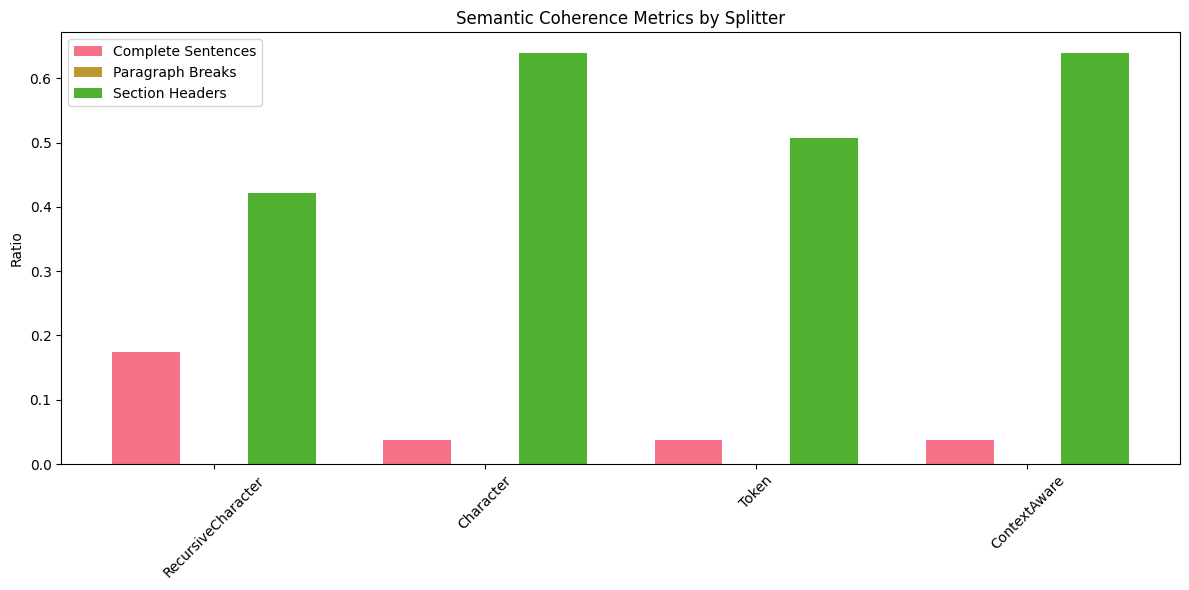

In [8]:
# Visualize semantic coherence
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_coherence))
width = 0.25

ax.bar(x - width, df_coherence['Complete Sentences Ratio'], width, label='Complete Sentences')
ax.bar(x, df_coherence['Paragraph Breaks Ratio'], width, label='Paragraph Breaks')
ax.bar(x + width, df_coherence['Section Headers Ratio'], width, label='Section Headers')

ax.set_ylabel('Ratio')
ax.set_title('Semantic Coherence Metrics by Splitter')
ax.set_xticks(x)
ax.set_xticklabels(df_coherence['Splitter'], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## Sample Output Analysis

In [10]:
def display_sample_chunks(results: Dict, num_samples=3):
    """Display sample chunks from each splitter."""
    for name, data in results.items():
        print(f"\n=== {name} Splitter Samples ===\n")
        
        # Get random samples
        samples = np.random.choice(data['chunks'], num_samples, replace=False)
        
        for i, sample in enumerate(samples, 1):
            print(f"Sample {i}:")
            print(f"Length: {len(sample.page_content)} characters")
            print(f"Source: {sample.metadata['source']}, Page: {sample.metadata['page']}")
            print("Content:")
            print("-" * 80)
            print(sample.page_content[:500] + "..." if len(sample.page_content) > 500 else sample.page_content)
            print("-" * 80)
            print()

# Display samples
display_sample_chunks(results)


=== RecursiveCharacter Splitter Samples ===

Sample 1:
Length: 743 characters
Source: ../public\jac_brochure.pdf, Page: 95
Content:
--------------------------------------------------------------------------------
photograph is affixed above, and are satisfied that:
(A) He/she is a case of Multiple Disability. His/her extent of permanent physical
impairment/disability has been evaluated as per guidelines (to be specified) for the disabilities
ticked below, and shown against the relevant disability in the table below:
Sr. Disability Affected Part Diagnosis Permanent physical impairment /
No. of Body mental disability (in %)
1. Locomotor disability @
2. Muscular Dystrophy
3. Leprosy cured
4. Dwarfism
5. Cer...
--------------------------------------------------------------------------------

Sample 2:
Length: 931 characters
Source: ../public\jac_brochure.pdf, Page: 10
Content:
--------------------------------------------------------------------------------
two categories i.e. CHANDIGARH Q

## Summary and Recommendations

Based on the evaluation results, we can make the following observations:

In [38]:
print("1. Chunk Size Consistency")
print(f"   - RecursiveCharacter: {df_results.loc[df_results['Splitter'] == 'RecursiveCharacter', 'Std Chunk Size'].values[0]:.2f} std dev")
print(f"   - Character: {df_results.loc[df_results['Splitter'] == 'Character', 'Std Chunk Size'].values[0]:.2f} std dev")
print(f"   - Token: {df_results.loc[df_results['Splitter'] == 'Token', 'Std Chunk Size'].values[0]:.2f} std dev")
print(f"   - ContextAware: {df_results.loc[df_results['Splitter'] == 'ContextAware', 'Std Chunk Size'].values[0]:.2f} std dev")

print("\n2. Processing Efficiency")
print(f"   - Fastest: {df_results.loc[df_results['Processing Time (s)'].idxmin(), 'Splitter']} ({df_results['Processing Time (s)'].min():.2f}s)")
print(f"   - Slowest: {df_results.loc[df_results['Processing Time (s)'].idxmax(), 'Splitter']} ({df_results['Processing Time (s)'].max():.2f}s)")

print("\n3. Semantic Coherence")
print(f"   - Best for complete sentences: {df_coherence.loc[df_coherence['Complete Sentences Ratio'].idxmax(), 'Splitter']}")
print(f"   - Best for paragraph preservation: {df_coherence.loc[df_coherence['Paragraph Breaks Ratio'].idxmax(), 'Splitter']}")

1. Chunk Size Consistency
   - RecursiveCharacter: 224.07 std dev
   - Character: 669.77 std dev
   - Token: 674.81 std dev
   - ContextAware: 669.77 std dev

2. Processing Efficiency
   - Fastest: ContextAware (0.00s)
   - Slowest: Token (0.04s)

3. Semantic Coherence
   - Best for complete sentences: RecursiveCharacter
   - Best for paragraph preservation: RecursiveCharacter


### Recommendations

1. **For General Use**:
   - RecursiveCharacterTextSplitter provides a good balance of speed and coherence
   - Best for most RAG applications

2. **For Maximum Coherence**:
   - ContextAwareSplitter preserves semantic structure better
   - Best for documents with important structural elements

3. **For Speed**:
   - CharacterTextSplitter is fastest
   - Best for simple documents or when processing time is critical

4. **For Token Control**:
   - TokenTextSplitter provides most consistent token counts
   - Best when working with specific LLM context windows

### Optimal Configuration

Based on these results, we recommend:
```python
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']
)
```

This configuration provides:
- Good semantic coherence
- Reasonable processing speed
- Consistent chunk sizes
- Effective context preservation